# Проект для «Викишоп» с BERT

Интернет-магазин «Викишоп» запускает новый сервис. Теперь пользователи могут редактировать и дополнять описания товаров, как в вики-сообществах. То есть клиенты предлагают свои правки и комментируют изменения других. Магазину нужен инструмент, который будет искать токсичные комментарии и отправлять их на модерацию. 

ЦЕЛЬ:

Обучить модель классифицировать комментарии на позитивные и негативные.
Критерий качества модели: F1 > 0.75

ОПИСАНИЕ ДАННЫХ:

ДАННЫЕ: `toxic_comments.csv`

- `text` — текст комментария
- `toxic` — целевой признак

ПЛАН РАБОТ:

Задача классификации текста состоит из 2-х этапов. 1-encoding или векторизация и 2-собственно классификация

Рассмотрим 3 сочетания этих этапов
1. Векторизация класическими средствами ML + классификация класическими средствами ML
2. Векторизация предобученной моделью + классификация класическими средствами ML
3. Векторизация предобученной моделью + классификация предобученной моделью

Для классической векторизации воспользуемся TF-IDF методом:
- Токенизируем, чистим и лемматизируем текст
- Удалим стоп слова и проведем векторизацию TF-IDF 

Для векторизации предобученной моделью возьмем BERT и проведем векторизацию с помощью эмбеддингов:
- Токенизируем текст, получим эмбеддинги

Для  классификации класическими средствами ML рассмотрим 2 модели:
- Логистическую регрессию
- Модель градиентного бустинга

Для вектоизации и классификации предобученной моделью возьмем готовую модель, уже ориентированную на класификацию комментариев по токсичности

Далее:
- Выберем лучшую модель и лучший тип векторизации
- Оценим ее качество на тестовой выборке
- Сделаем выводы

*!!! На работу всей тетрадки на локальном ноуте без GPU уходит около 20 минут !!!*

*ИМПОРТЫ*

In [1]:
!pip install nltk -q
!pip install catboost -q
!pip install torch -q
!pip install transformers -q

In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import re
import time

In [3]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize, pos_tag
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
from nltk.corpus import stopwords as nltk_stopwords
nltk.download('stopwords')
stopwords = list(set(nltk_stopwords.words('english')))

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
#from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)
from sklearn.metrics import f1_score

In [5]:
import torch
from transformers import (
    BertTokenizer, 
    BertModel,
    RobertaTokenizer, 
    RobertaForSequenceClassification
)

*КОНСТАНТЫ*

In [6]:
RANDOM_STATE = 42

*ПОЛЬЗОВАТЕЛЬСКИЕ ФУНКЦИИ*

In [7]:
def get_wordnet_pos(tag):
    """
    Перевод тегов POS из NLTK в формат, понятный WordNetLemmatizer
    Для того чтобы учитывать части речи при лемматизации
    """
    if tag.startswith('J'):
        return nltk.corpus.wordnet.ADJ
    elif tag.startswith('V'):
        # Уточняем обработку глаголов
        if tag in ['VBD', 'VBN']:  # прошедшее время или причастие прошедшего времени
            return nltk.corpus.wordnet.VERB
        elif tag in ['VB', 'VBP', 'VBG']:  # неопределённая форма, настоящее время, причастие настоящего времени
            return nltk.corpus.wordnet.VERB
        else:
            return nltk.corpus.wordnet.NOUN
    elif tag.startswith('N'):
        return nltk.corpus.wordnet.NOUN
    elif tag.startswith('R'):
        return nltk.corpus.wordnet.ADV
    else:
        return nltk.corpus.wordnet.NOUN  #Для всех неизвестных тегов возвращаем NOUN по умолчанию

In [8]:
def lemmatize(text):
    """
    Функция для лемматизации с учетом части речи
    """
    # Токенизация текста и получение тегов POS
    tokens = word_tokenize(text)
    tagged = pos_tag(tokens)

    # Лемматизация с учётом части речи
    lemmatized_tokens = [lem.lemmatize(token, get_wordnet_pos(pos)) for token, pos in tagged]
    return ' '.join(lemmatized_tokens)

In [9]:
def clear_text(text):
    """
    Функция для очистки текста 
    Регулярка оставляет только латинские буквы
    Все символы, пунктуацию и пробелы убираем
    Апостров оставляем
    """
    text = text.lower()
    text = re.sub(r'[^a-z\']', ' ', text).split()
    return " ".join(text)

## Подготовка

### Загрузка данных

In [10]:
try:
    toxic_comments = pd.read_csv('toxic_comments.csv', index_col=0)
except:
    toxic_comments = pd.read_csv(
        'https://code.s3.yandex.net/datasets/toxic_comments.csv', index_col=0)

In [11]:
toxic_comments.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 159292 entries, 0 to 159450
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    159292 non-null  object
 1   toxic   159292 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 3.6+ MB


In [12]:
toxic_comments.head()

,text,toxic
0,Explanation\nWhy the edits made under my usern...,0
1,D'aww! He matches this background colour I'm s...,0
2,"Hey man, I'm really not trying to edit war. It...",0
3,"""\nMore\nI can't make any real suggestions on ...",0
4,"You, sir, are my hero. Any chance you remember...",0


In [13]:
df = toxic_comments

In [14]:
df.head()

,text,toxic
0,Explanation\nWhy the edits made under my usern...,0
1,D'aww! He matches this background colour I'm s...,0
2,"Hey man, I'm really not trying to edit war. It...",0
3,"""\nMore\nI can't make any real suggestions on ...",0
4,"You, sir, are my hero. Any chance you remember...",0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 159292 entries, 0 to 159450
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    159292 non-null  object
 1   toxic   159292 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 3.6+ MB


### Векторизация TF-IDF

#### Очистка и лемматизация

*Для лемматизации английского теста возьмем WordNetLemmatizer из библиотеки nltk*

In [16]:
# Инициализация лемматизатора
lem = WordNetLemmatizer()

*Для очистки и лемматизации воспользуемся пользовательскими функциями*

In [17]:
start_time = time.time()
df['clear_text'] = df['text'].apply(clear_text)
df['lem_text'] = df['clear_text'].apply(lemmatize)
df = df.drop(['text', 'clear_text'], axis=1)
end_time = time.time()
print(f"Время выполнения: {end_time-start_time} секунд")
df.head()

Время выполнения: 761.3280463218689 секунд


,toxic,lem_text
0,0,explanation why the edits make under my userna...
1,0,d'aww he match this background colour i 'm see...
2,0,hey man i 'm really not try to edit war it 's ...
3,0,more i ca n't make any real suggestion on impr...
4,0,you sir be my hero any chance you remember wha...


#### Разделим данные на обучающую и тестовую выборки

*Разбивать будем сохраня баланс классов исходных данных*

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    df.lem_text, df.toxic, test_size=0.2, 
    stratify=df.toxic, random_state=RANDOM_STATE)

#### Векторизуем наши выборки

*Вообще планирую собрать пайплайн и векторизацию проводить там, поэтому данный шаг нам нужен только для информативности*

*При векторизации удалим стоп слова и посмотрим размерность*

In [19]:
# считаем величину TF-IDF для обучающей выборки
tf_idf = TfidfVectorizer(stop_words=stopwords)
tf_idf_train = tf_idf.fit_transform(X_train)
tf_idf_train.shape

(127433, 136199)

In [20]:
# считаем величину TF-IDF для тестовой выборки
tf_idf_test = tf_idf.transform(X_test)
tf_idf_test.shape

(31859, 136199)

*Размерность адекватная*

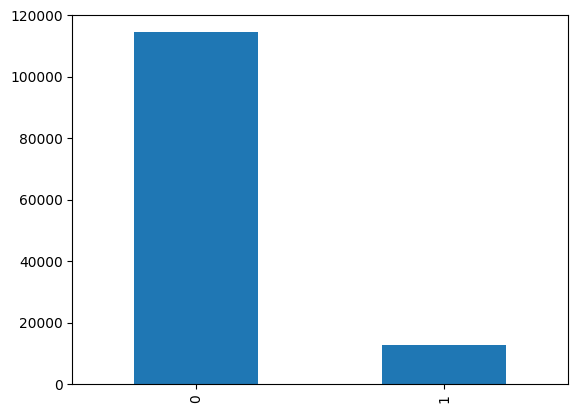

In [21]:
# проверяем распределение классов в обучающей выборке
y_train.value_counts().plot.bar();

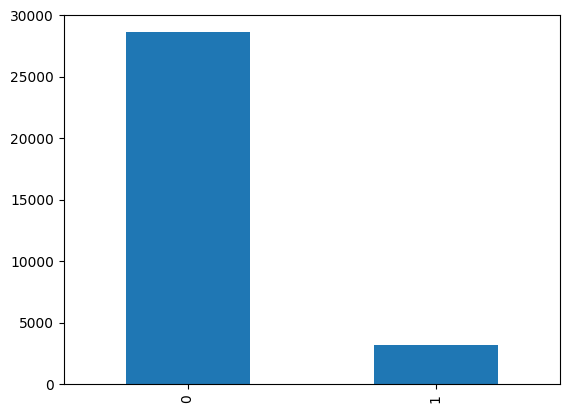

In [22]:
# проверяем распределение классов в тестовой выборке
y_test.value_counts().plot.bar();

*На лицо огромный дисбаланс (примерно в 10 раз). В обоих выборках распределение выглядит одинаково. Для борьбы с дисбалансом классов используют различные техники, такие как добавление синтетических данных, изменение порога или использование специализированных метрик оценки, например, F1-меры. Нам важно учесть этот дисбалланс, поэтому укажем модели соотношение классов*

*Качество модели будет оцениваться по F1 мере. Метрика F1 — это гармоническое среднее между точностью (precision) и полнотой (recall). Она особенно полезна в случаях, когда классы в данных несбалансированы*

### Векторизация на эмбедингах

*Векторизацию будем проводить с помощью предобученой модели из семейства BERT*

*В целях экономии времени на расчеты возьмем выборку 400 элементов*

In [23]:
df_bert = toxic_comments.sample(n=400, random_state=RANDOM_STATE).reset_index(drop=True)

#### Загрузим токенизатор и модель (bert)

In [24]:
start_time = time.time()
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')  # (uncased - не чувствительна к регистру)
bert_model = BertModel.from_pretrained('bert-base-uncased')
end_time = time.time()
print(f"Время загрузки: {end_time-start_time} секунд")

Время загрузки: 1.8516416549682617 секунд


#### Токенизация текстов и получение эмбеддингов

In [25]:
# Размер батча
batch_size = 40

embeddings_list = []
labels_list = []  
for i in range(0, len(list(df_bert['text'])), batch_size):
    start_time = time.time()
    batch_texts = list(df_bert['text'][i:i+batch_size])
    inputs = tokenizer(batch_texts, padding=True, truncation=True, return_tensors="pt")

    with torch.no_grad():
        outputs = bert_model(**inputs)
        batch_embeddings = outputs.last_hidden_state[:, 0, :]  # CLS токен
        embeddings_list.append(batch_embeddings)
    
    # Собираем соответствующие метки таргета
    labels_batch = torch.tensor(list(df_bert['toxic'][i:i+batch_size]), dtype=torch.long)
    labels_list.append(labels_batch)

    end_time = time.time()
    print(f"Время выполнения батча {i//batch_size + 1}: {end_time-start_time} секунд")

# Объединяем всех эмбеддингов в один тензор
embeddings = torch.cat(embeddings_list, dim=0)
labels = torch.cat(labels_list, dim=0)

Время выполнения батча 1: 8.524051904678345 секунд
Время выполнения батча 2: 15.070189714431763 секунд
Время выполнения батча 3: 13.891014575958252 секунд
Время выполнения батча 4: 15.614789009094238 секунд
Время выполнения батча 5: 13.437657833099365 секунд
Время выполнения батча 6: 15.500998497009277 секунд
Время выполнения батча 7: 15.550976276397705 секунд
Время выполнения батча 8: 11.817291736602783 секунд
Время выполнения батча 9: 12.680333137512207 секунд
Время выполнения батча 10: 15.37283730506897 секунд


*В коде, который мы используем, `inputs` формируется с помощью токенизатора `tokenizer`, и этот токенизатор автоматически добавляет `attention_mask` в возвращаемый словарь. Когда мы передаём `**inputs` в модель bert_model, все элементы словаря inputs, включая attention_mask, распаковываются и передаются в модель как отдельные аргументы.Таким образом, даже если attention_mask не указана явно при вызове bert_model, она всё равно передаётся, потому что уже содержится в словаре inputs. Это позволяет модели корректно обрабатывать последовательности с разной длиной после падинга, не требуя от нас явного указания attention_mask. Это относится и к конкретному положению слова в предложении. Паддинг и обрезка = True задаем явно*

#### Разделим данные на обучающую и тестовую выборки

In [26]:
X_bert_train, X_bert_test, y_bert_train, y_bert_test = train_test_split(
 embeddings, labels, test_size=0.2, random_state=RANDOM_STATE, stratify=labels,
)

## Обучение

### Векторизация и классификация классическими средствами ML

*Вообще-то нам нужна лучшая модель, поэтому логично было бы собрать все в один пайплайн и перебрать гиперпараметры для всех. Но хочу посмотреть как поведут себя модельки по времени в процессе подбора. Поэтому сделаю 2 пайплайна. GridSearchCV поищем лучшие гиперпараметры для моделей и в  векторизаторе потестируем разное количество признаков*

#### TF-IDF + Логистическая регрессия 

In [27]:
start_time = time.time()
pipe_log_reg = Pipeline(
    [
        ('preprocessor', TfidfVectorizer(stop_words=stopwords)),
        ('models', LogisticRegression())
    ]
)
param_grid_log_reg = [
    
     # словарь для модели LogisticRegression()
    {
        'preprocessor': [TfidfVectorizer(stop_words=stopwords)],
        #'preprocessor__max_features': range (5000, 7000),
        'models': [LogisticRegression(class_weight={0: 1, 1: 7})],
        'models__random_state' : [RANDOM_STATE],
        'models__C': [0.5, 1, 1.5, 1.75],
        'models__solver': ['liblinear'],
        'models__penalty': ['l1', 'l2']
    }
]
# Не забываем про стратификацию
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

gs_log_reg = GridSearchCV(
    pipe_log_reg, 
    param_grid_log_reg, 
    cv=cv,
    scoring='f1',                          
    n_jobs=-1,
)
gs_log_reg.fit(X_train, y_train)
end_time = time.time()
print(f"Время выполнения: {end_time-start_time} секунд")

Время выполнения: 72.69785594940186 секунд


In [28]:
print('Лучшая модель и её параметры:\n\n', gs_log_reg.best_estimator_)
print ('Метрика лучшей модели на кроссвалидации:', gs_log_reg.best_score_)

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 TfidfVectorizer(stop_words=['up', 'such', 'weren', 'no', 'he',
                                             'now', 'are', 'them', 'which',
                                             'by', 'just', 'off', 'don', 'this',
                                             "shouldn't", 'yours', 'haven', 'm',
                                             "mightn't", "didn't", "wasn't",
                                             'more', "it's", 't', 'here',
                                             'while', 'again', 'an', 'whom',
                                             "couldn't", ...])),
                ('models',
                 LogisticRegression(C=1.75, class_weight={0: 1, 1: 7},
                                    random_state=42, solver='liblinear'))])
Метрика лучшей модели на кроссвалидации: 0.7636166564031933


*Посмотрим на влияние гиперпараметров*

In [29]:
result_log_reg = pd.DataFrame(gs_log_reg.cv_results_)
result_log_reg = result_log_reg.drop(['std_fit_time', 'mean_score_time', 
                      'std_score_time', 'param_preprocessor', 
                      'param_models__random_state', 'param_models',
                      'param_models__solver', 'params'], axis=1)
result_log_reg.sort_values('rank_test_score')

,mean_fit_time,param_models__C,param_models__penalty,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
7,15.463917,1.75,l2,0.765287,0.762543,0.763019,0.763617,0.001197,1
5,16.670173,1.5,l2,0.765221,0.762408,0.761202,0.762944,0.001684,2
6,22.240833,1.75,l1,0.763806,0.755551,0.761833,0.760397,0.003520,3
4,15.382232,1.5,l1,0.763774,0.756454,0.760765,0.760331,0.003004,4
3,17.511069,1,l2,0.761710,0.760437,0.758577,0.760241,0.001287,5
2,18.265183,1,l1,0.758972,0.756178,0.757204,0.757451,0.001154,6
1,26.711806,0.5,l2,0.758099,0.751506,0.752317,0.753974,0.002935,7
0,16.534576,0.5,l1,0.754071,0.750467,0.751290,0.751943,0.001542,8


#### CatBoost классификатор

*Мы знаем, что CatBoost сам под капотом векторизирует тексты. Можем загрузить сырой текст и он его отлично прожует. Однако, мы так же знаем, что он не очищает и не лемматизирует текст. Поэтому для улучшения метрики мы обучим CatBoost на лемматизированном тексте*

In [30]:
X_cb = df.drop(['toxic'], axis=1)
y_cb = df['toxic']
X_cb_train, X_cb_test, y_cb_train, y_cb_test = train_test_split(X_cb, y_cb, test_size=0.2, random_state=RANDOM_STATE, stratify=y_cb)

In [31]:
start_time = time.time()

pipe_catb = Pipeline([
    ('models',CatBoostClassifier(verbose=0, text_features=['lem_text']))  # Отключаем вывод логов для краткости и указываем список! столбцов с текстом
])

param_grid_catb = {
    'models__iterations': [500],
    'models__learning_rate': [0.5],
    'models__depth': [4, 6],
    'models__scale_pos_weight':[7]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
gs_catb = GridSearchCV(
    pipe_catb,
    param_grid=param_grid_catb,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

gs_catb.fit(X_cb_train, y_cb_train)  
end_time = time.time()

print(f"Время выполнения: {end_time-start_time} секунд")

Время выполнения: 273.80322790145874 секунд


In [32]:
print('Лучшая модель и её параметры:\n\n', gs_catb.best_estimator_)
print ('Метрика лучшей модели на кроссвалидации:', gs_catb.best_score_)

Лучшая модель и её параметры:

 Pipeline(steps=[('models',
                 <catboost.core.CatBoostClassifier object at 0x0000019CD6622460>)])
Метрика лучшей модели на кроссвалидации: 0.753745221259757


In [33]:
result_catb = pd.DataFrame(gs_catb.cv_results_)
result_catb = result_catb.drop(['std_fit_time', 'mean_score_time', 
                      'std_score_time', 
                      
                      'params'], axis=1)
result_catb.sort_values('rank_test_score')

,mean_fit_time,param_models__depth,param_models__iterations,param_models__learning_rate,param_models__scale_pos_weight,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
1,199.397868,6,500,0.5,7,0.754456,0.755597,0.751182,0.753745,0.001871,1
0,153.179231,4,500,0.5,7,0.737260,0.747085,0.735016,0.739787,0.005241,2


*ВЫВОД: Модели показывают похожий результат. Значение средней метрики удовлетворяет поставленной задаче*

### Векторизация на эмбедингах BERT и классификация классическими средствами ML

#### Эмбединги BERT + Логистическая регрессия 

In [34]:
start_time = time.time()
pipe_bert_log_reg = Pipeline(
    [
        ('models', LogisticRegression())
    ]
)
param_grid_bert_log_reg = [
    
     # словарь для модели LogisticRegression()
    {
        'models': [LogisticRegression(class_weight={0: 1, 1: 7})],
        'models__random_state' : [RANDOM_STATE],
        'models__C': [0.5, 1, 1.5, 1.75],
        'models__solver': ['liblinear'],
        'models__penalty': ['l1', 'l2']
    }
]
# Не забываем про стратификацию
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

gs_bert_log_reg = GridSearchCV(
    pipe_bert_log_reg, 
    param_grid_bert_log_reg, 
    cv=cv,
    scoring='f1',                          
    n_jobs=-1,
)
gs_bert_log_reg.fit(X_bert_train, y_bert_train)
end_time = time.time()
print(f"Время выполнения: {end_time-start_time} секунд")

Время выполнения: 5.1899871826171875 секунд


In [35]:
print('Лучшая модель и её параметры:\n\n', gs_bert_log_reg.best_estimator_)
print ('Метрика лучшей модели на кроссвалидации:', gs_bert_log_reg.best_score_)

Лучшая модель и её параметры:

 Pipeline(steps=[('models',
                 LogisticRegression(C=1, class_weight={0: 1, 1: 7},
                                    random_state=42, solver='liblinear'))])
Метрика лучшей модели на кроссвалидации: 0.7199223354829761


In [36]:
result_bert_log_reg = pd.DataFrame(gs_bert_log_reg.cv_results_)
result_bert_log_reg = result_bert_log_reg.drop(['std_fit_time', 'mean_score_time', 
                      'std_score_time', 'param_models__random_state', 'param_models',
                      'param_models__solver', 'params'], axis=1)
result_bert_log_reg.sort_values('rank_test_score').head()

,mean_fit_time,param_models__C,param_models__penalty,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
3,0.045878,1,l2,0.695652,0.727273,0.736842,0.719922,0.017601,1
1,0.120101,0.5,l2,0.695652,0.727273,0.700000,0.707642,0.013994,2
5,0.107459,1.5,l2,0.636364,0.727273,0.736842,0.700159,0.045279,3
7,0.055337,1.75,l2,0.636364,0.727273,0.736842,0.700159,0.045279,3
2,0.043549,1,l1,0.454545,0.500000,0.666667,0.540404,0.091189,5


*ВЫВОД: Эмбединги полученные с помощью BERT не дали необходимого результата по метрике. Возможно имеет смысл рассмотреть другой подход (с пулингом по токенам текста, такие как mean-pooling или max-pooling) вместо подхода с CLS-токеном. Эти методы позволяют учитывать вклад каждого токена, что может быть особенно полезно для задач, где информация равномерно распределена по тексту... Однако, плюсом использования эмбедингов BERT по сравнению с классическим ML, может быть то, что для получения примерно похожей метрики эмбедингам  оказалось достаточно выборки в 400, а TF-IDF понадобилось околоо 160 000 (в 400 раз больше). Времени на подготовку данных с BERT ушло гораздо меньше, чем в классических вариантах... С ним, конечно, удобнее работать. Не нужно отдельно чистить, отдельно лемматизировать и т. д. Посмотрим, удастся ли улучшить качество модели пулингом. Еще можно попробовать дообучить BERT на нашем датасете*

### Предобученная модель RobertaForSequenceClassification

*Модель предобучена непосредственно для задачи бинарной классификации на токсичность комментариев. Взята с Hugieng Face*

#### Сделаем выборку для Роберты

*Для чистоты эксперимента выделим как и для других моделей 3 валидационных выборки и посчитаем среднюю метрику*

In [37]:
df_rob = toxic_comments.sample(n=400, random_state=42).reset_index(drop=True)

In [38]:
X_rob_train, X_rob_test, y_rob_train, y_rob_test = train_test_split(
    df_rob.text, df_rob.toxic, test_size=0.2, 
    stratify=df_rob.toxic, random_state=RANDOM_STATE)

In [39]:
train_texts = list(X_rob_train)
train_labels = list(y_rob_train)

#### Получим предсказания, посчитаем метрику

In [40]:
start_time = time.time()
# Загрузка токенизатора и модели
tokenizer = RobertaTokenizer.from_pretrained('s-nlp/roberta_toxicity_classifier')
model = RobertaForSequenceClassification.from_pretrained('s-nlp/roberta_toxicity_classifier')

# Инициализация стратифицированной KFold
stratified_kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

f1_scores = []

for train_index, val_index in stratified_kfold.split(train_texts, train_labels):
    train_fold_texts, val_fold_texts = [train_texts[i] for i in train_index], [train_texts[i] for i in val_index]
    train_fold_labels, val_fold_labels = [train_labels[i] for i in train_index], [train_labels[i] for i in val_index]

    # Токенизация текста по каждой валидационной выборке
    val_inputs = tokenizer(val_fold_texts, padding=True, truncation=True, return_tensors="pt")

    # Получение предсказаний для валидационной выборки
    with torch.no_grad():
        val_outputs = model(**val_inputs)
        val_predictions = torch.argmax(val_outputs.logits, dim=1)

    # Расчет F1 меры для текущей выборки
    f1 = f1_score(val_fold_labels, val_predictions.numpy(), average='binary')
    f1_scores.append(f1)
    print(f"F1 score for fold {len(f1_scores)}: {f1}")
end_time = time.time()
print(f"Время выполнения: {end_time-start_time} секунд")


Some weights of the model checkpoint at s-nlp/roberta_toxicity_classifier were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


F1 score for fold 1: 0.8571428571428571
F1 score for fold 2: 0.9565217391304348
F1 score for fold 3: 0.9600000000000001
Время выполнения: 113.67068862915039 секунд


In [41]:
# Средняя F1-мера 
f1_rob = sum(f1_scores) / len(f1_scores)
print ('Метрика модели на кроссвалидации:', f1_rob)

Метрика модели на кроссвалидации: 0.9245548654244305


*ВЫВОД: вот эта метрика конечно впечатляет!!!!*

## Выводы

### Посмотрим на сравнительную табличку результатов

In [42]:
data = {
    'Модель': [
               'TF-IDF+LogisticRegression', 
               'TF-IDF+CatBoost', 
               'Embeddings(BERT)+LogisticRegression',  
               'RobertaForSequenceClassification'
    ],
    'F1-мера на кроссвалидации': [
                gs_log_reg.best_score_, 
                gs_catb.best_score_,
                gs_bert_log_reg.best_score_,
                f1_rob
    ]
}
results = pd.DataFrame(data)

In [43]:
results

,Модель,F1-мера на кроссвалидации
0,TF-IDF+LogisticRegression,0.763617
1,TF-IDF+CatBoost,0.753745
2,Embeddings(BERT)+LogisticRegression,0.719922
3,RobertaForSequenceClassification,0.924555


*ВЫВОД: Единственная модель, которая удовлетворяет поставленной задаче F1 > 0.75 это предобученная модель RobertaForSequenceClassification. Данная модель предобучена непосредственно для задачи бинарной классификации комментариев на токсичные и нейтральные. Модель относительно не тяжелая и довольно быстрая*

### Получим метрику лучшей модели на тестовой выборке

In [44]:
test_texts = list(X_rob_test)
test_labels = list(y_rob_test)

test_inputs = tokenizer(test_texts, padding=True, truncation=True, return_tensors="pt")
with torch.no_grad():
    test_outputs = model(**test_inputs)
    test_predictions = torch.argmax(test_outputs.logits, dim=1)

In [45]:
f1_rob_test = f1_score(test_labels, test_predictions)
print ('Метрика F1- мера лучшей модели на тестовой выборке:', f1_rob_test)

Метрика F1- мера лучшей модели на тестовой выборке: 0.9


*ВЫВОД: Для решения поставленной задачи по бинарной классификации комментариев на токсичные и нейтральные рекомендую использовать предобученную модель RobertaForSequenceClassification. Однако, для решения похожих задач, для которых отсутствуют готовые предобученные модели, можно использовать связку TF-IDF + Логистическая регрессия. Несмотря на нашествие трансфомреров эта связка - хороший бейзлайн, который кроме всего прочего еще очень легкий и быстрый. Поэтому эту связку можно использовать там, где важна скорость или как первое, быстрое решение*